# Predicting Loan Defaults: Analyzing Key Factors Influencing Borrower Behavior

Financial loans are agreements in which a lender provides a borrower with a specified amount of money, which the borrower agrees to repay, typically with interest, over a predetermined period. Financial loans are crucial for driving growth, ensuring financial security, and fostering economic stability. They enable individuals and businesses to invest in opportunities that contribute to both personal and societal progress. Evaluating the risks associated with financial loans is essential for safeguarding both lenders and borrowers, promoting responsible lending practices, and ensuring a stable financial system.

In the dynamic landscape of financial services, it's essential for lenderkoqs to understand and manage loan defaults. The objective of my study is to predict loan defaults using various borrower characteristics and loan attributes. As financial institutions encounter growing pressure to reduce risk while optimizing profitability, a robust predictive model can greatly improve decision-making processes.

The primary objective of this project is to develop a machine learning model that accurately predicts the likelihood of a borrower defaulting on a loan. The expectation is that the model will provide insights into critical factors influencing the loan repayment behavior using the historical data points such as Loan Amount, Rate of Interest, Credit Score, Loan Pre-Approval, Purpose of Loan, etc., and help making decisions that can help mitigate the risk of loan default. 

The target for this model will be binary classification, where the output indicates whether a loan will default (1) or not (0). This classification will enable lenders to make informed decisions when approving loans, adjusting terms, or implementing risk mitigation strategies such as larger downpayment, higher interest rate, financial planning education, etc.,

To achieve this objective, I am planning to use the dataset, "Loan_Default.CSV",  which contains a wide array of features related to loan applicants such as 

1. Credit Score - Indicates the borrower’s creditworthiness and likelihood of repaying.
2. Rate of Interest - Affects the repayment burden; higher rates may increase default risk.
3. Pre-Approval - Suggests initial creditworthiness, reducing the chance of default.
4. Loan Amount - Determines the debt load; larger amounts may pose higher risk.
5. Loan Purpose - Provides context for the usage of loan amoubt, influencing repayment behavior based on necessity or risk level.

The analysis will involve several steps, including data preprocessing, exploratory data analysis (EDA), feature engineering, model selection and model evaluation. 

Objective of Milestone#1 is to perform Exploratory Data Analysis and Visualization to find answers to below questions
1. What is the role of key demographic factor(Gender) in influencing loan default rates?
2. How does the distribution of credit scores vary among borrowers who default versus those who do not?
3. Does Pre-Approval Status influence the loan repayment status and if yes, to what extent?
4. Is there a significant difference in loan amounts between defaulting and non-defaulting borrowers?
5. What is the relationship between the rate of interest and the probability of loan default, and how does interest rate variation impact default rates?


## Importing required libraries

In [3]:
import pandas as pd # Import the pandas library for data manipulation and analysis
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib for creating visualizations
import seaborn as sns # Importing the seaborn library for advanced data visualization, built on top of matplotlib

## 1. Loading the dataset into dataframe and performing initial study about dataset

In [4]:
# Loading the dataset into Pandas dataframe
df = pd.read_csv('Loan_Default.csv')

# Display the first 5 rows of the DataFrame to get an initial look at the data
print(df.head(5))

# Retreiving the dimensions of the DataFrame (number of rows, number of columns)
print('\nInitial Dimension of Dataset:\n',(df.shape))

FileNotFoundError: [Errno 2] No such file or directory: 'Loan_Default.csv'

### Result: It is evident that the data is loaded into dataframe as expected and the dataset contains wide variety of features and we have a binary target variable

## 2. Validate the dataset for missing values

In [ ]:
# Computing the total number of missing (null) values in each column of the DataFrame
NaN_values = df.isnull().sum()

# Converting the result into a DataFrame for better formatting and readability
NaN_values_df = pd.DataFrame(NaN_values, columns=['Null Values'])

# Displaying the DataFrame showing the count of null values per column
print(NaN_values_df)

                           Null Values
ID                                   0
year                                 0
loan_limit                        3344
Gender                               0
approv_in_adv                      908
loan_type                            0
loan_purpose                       134
Credit_Worthiness                    0
open_credit                          0
business_or_commercial               0
loan_amount                          0
rate_of_interest                 36439
Interest_rate_spread             36639
Upfront_charges                  39642
term                                41
Neg_ammortization                  121
interest_only                        0
lump_sum_payment                     0
property_value                   15098
construction_type                    0
occupancy_type                       0
Secured_by                           0
total_units                          0
income                            9150
credit_type              

### Result: Based on the results, it is clear that there are features where the values are missing(NaN) and we will need address the missing values in upcoming milestones

## 3. Validate the Target Variable

In [ ]:
# Definining the Target Variable that will be used in analysis
column_name = 'Status'

# Counting unique values and their occurrences in the specified column
unique_value_counts = df[column_name].value_counts()

# Displaying the unique values and their counts
print(unique_value_counts)

Status
0    112031
1     36639
Name: count, dtype: int64


### Result: It is evident that all the records have value in Target Variable and the Target Variable is unambiguous and it is binary

## 4. Validate the Data Type of features in the dataset

In [ ]:
# Retrieving the data types of each column
data_types = df.dtypes

# Creating a DataFrame to display the column names and their data types
data_types_df = pd.DataFrame(data_types, columns=['Data Type'])

# Displaying the results to check the list of DataTypes of values in each column
print(data_types_df)

                          Data Type
ID                            int64
year                          int64
loan_limit                   object
Gender                       object
approv_in_adv                object
loan_type                    object
loan_purpose                 object
Credit_Worthiness            object
open_credit                  object
business_or_commercial       object
loan_amount                   int64
rate_of_interest            float64
Interest_rate_spread        float64
Upfront_charges             float64
term                        float64
Neg_ammortization            object
interest_only                object
lump_sum_payment             object
property_value              float64
construction_type            object
occupancy_type               object
Secured_by                   object
total_units                  object
income                      float64
credit_type                  object
Credit_Score                  int64
co-applicant_credit_type    

### Result: Based on the results, some columns shows clear data type while others are showing the data type as "Object". For example, the feature "Age" showing the data type as object.  A further probe is required to understand the data type

## 5. Check for features that do not have a clear data type value

In [ ]:
# Checking for columns with more than one data type
mixed_type_columns = {}
for column in df.columns:
    unique_types = df[column].apply(type).unique()
    if len(unique_types) > 1:
        mixed_type_columns[column] = unique_types

# Displaying columns with mixed types
if mixed_type_columns:
    print("Columns with more than one data type:")
    for col, types in mixed_type_columns.items():
        print(f"{col}: {types}")
else:
    print("No columns contain more than one data type.")

Columns with more than one data type:
loan_limit: [<class 'str'> <class 'float'>]
approv_in_adv: [<class 'str'> <class 'float'>]
loan_purpose: [<class 'str'> <class 'float'>]
Neg_ammortization: [<class 'str'> <class 'float'>]
age: [<class 'str'> <class 'float'>]
submission_of_application: [<class 'str'> <class 'float'>]


### Result: There are 6 features that have values involving multiple data type, therefore it is important to important to investigate the values on these feature

In [ ]:
# Checking for the number of data types in each column after removing the NaN values

# Removing NaN values
data_cleaned = df.dropna()

# Checking for columns with more than one data type
mixed_type_columns = {}
for column in data_cleaned.columns:
    unique_types = data_cleaned[column].apply(type).unique()
    if len(unique_types) > 1:
        mixed_type_columns[column] = unique_types

# Displaying columns with mixed types
if mixed_type_columns:
    print("Columns with more than one data type:")
    for col, types in mixed_type_columns.items():
        print(f"{col}: {types}")
else:
    print("No columns contain more than one data type.")

No columns contain more than one data type.


### Result: After removing the rows with NaN values, it is clear that the data in all the features have consistent datatype

## Exploratory Data Analysis

### 1. Influence of key Democratic Factor(Gender) in Loan Default Rate

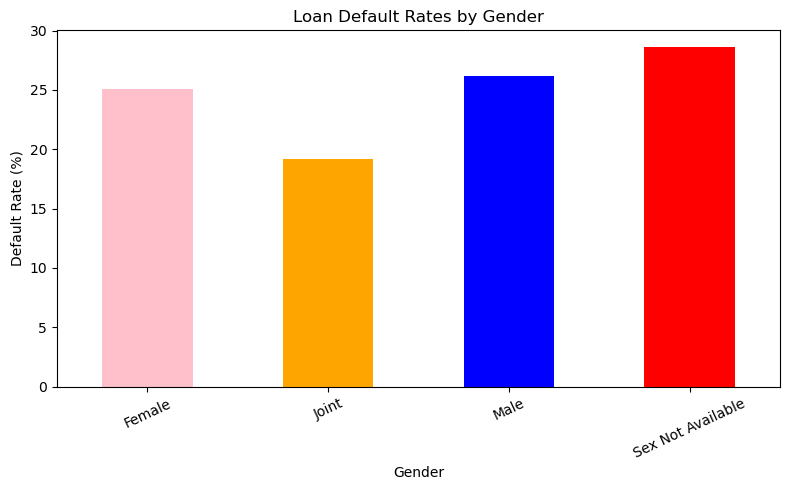

In [ ]:
# Creating a new binary column 'Default' where Status == 1 is mapped to 1 (defaulted), else 0 (not defaulted)
df['Default'] = df['Status'].apply(lambda x: 1 if x == 1 else 0)

# Calculating the average default rate for each gender and converting it to percentage
default_rates = df.groupby('Gender')['Default'].mean() * 100

# Defining the figure size for the plot
plt.figure(figsize=(8, 5))

# Creating a bar plot for default rates by gender with custom colors
default_rates.plot(kind='bar', color=['pink', 'orange', 'blue', 'red'])

# Defining the title and axis labels
plt.title('Loan Default Rates by Gender')
plt.xlabel('Gender')
plt.ylabel('Default Rate (%)')

# Rotating x-axis labels for better readability
plt.xticks(rotation=25)

# Adjusting layout to minimize overlaps between elements like titles, axis labels, and tick labels
plt.tight_layout()

# Displaying the plot
plt.show()

### Result: The graphical analysis reveals a significant difference in default rates based on gender. It appears that loan applications with "Joint" applicants have the lowest default rate. This finding suggests further investigation into factors such as the dependents of joint applicants, their marital status, and other demographic characteristics.

## 2. Distribution of Credit Scores (Default vs Non-Default cases)

<Figure size 1000x600 with 0 Axes>

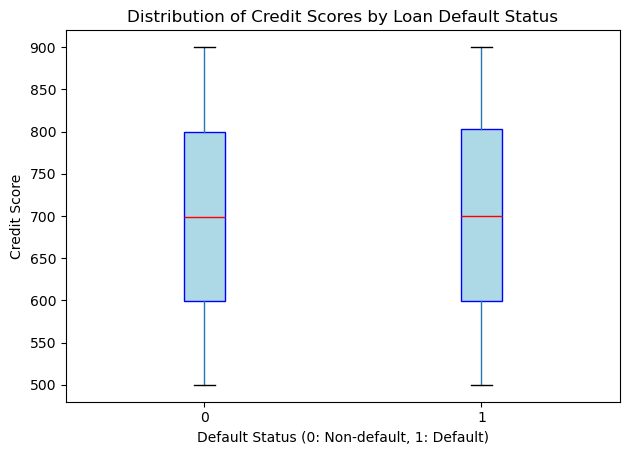

In [ ]:
# Filtering the data to include only rows where 'Credit_Score' and 'Status' are not null
data_filtererd = df[df['Credit_Score'].notna() & df['Status'].notna()]

# Creating a binary 'Default' column based on 'Status' (1 = default, 0 = non-default)
data_filtererd['Default'] = df['Status'].apply(lambda x: 1 if x == 1 else 0)

# Defining the figure size for the plot
plt.figure(figsize=(10, 6))

# Creating a boxplot of Credit Score distribution by Default status
data_filtererd.boxplot(column='Credit_Score', by='Default', grid=False, patch_artist=True,
             boxprops=dict(facecolor='lightblue', color='blue'),
             medianprops=dict(color='red'))

# Defining the title and axis labels
plt.title('Distribution of Credit Scores by Loan Default Status')
plt.suptitle('')  # Suppress the default title to keep it clean
plt.xlabel('Default Status (0: Non-default, 1: Default)')
plt.ylabel('Credit Score')

# Adjusting layout to minimize overlaps between elements like titles, axis labels, and tick labels
plt.tight_layout()

# Displaying the plot
plt.show()

### Result: The box plot reveals similarities in credit score distributions between defaulting and non-defaulting borrowers. This suggests that the factor "Credit Score" alone may not fully account for default risk. Further analysis incorporating additional variables might be necessary to develop a more comprehensive understanding of loan default.

## 3. Influence of Interest Rate in Loan Default Status

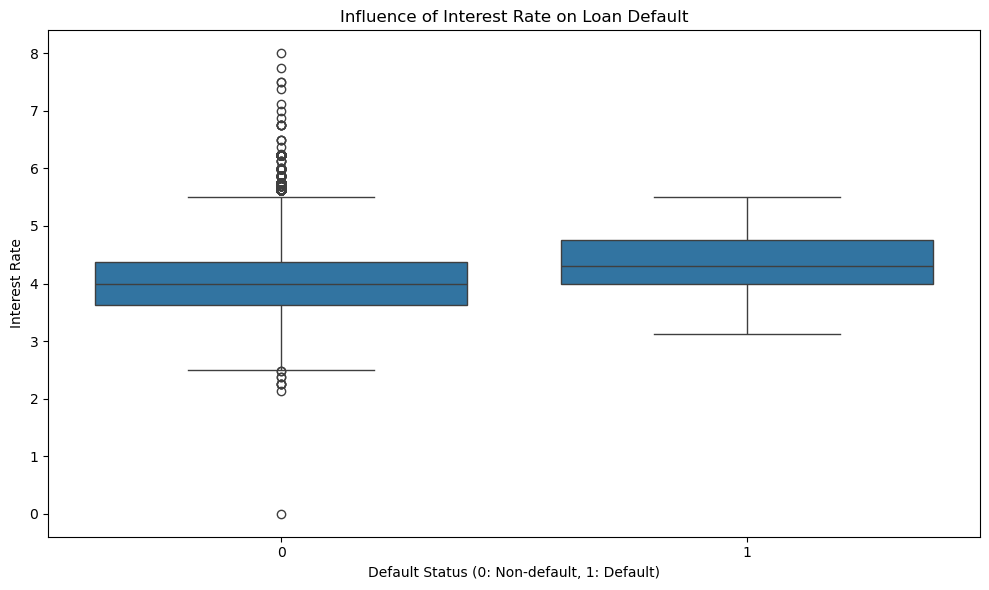

In [ ]:
# Step 1: Filter out rows with missing 'rate_of_interest' or 'Status'
df_clean = df[df['rate_of_interest'].notna() & df['Status'].notna()].copy()

# Step 2: Create a binary 'Default' column based on 'Status'
df_clean['Default'] = df_clean['Status'].apply(lambda x: 1 if x == 1 else 0)

# Step 3: Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Default', y='rate_of_interest', data=df_clean)

# Add titles and labels
plt.title('Influence of Interest Rate on Loan Default')
plt.xlabel('Default Status (0: Non-default, 1: Default)')
plt.ylabel('Interest Rate')

# Show the plot
plt.tight_layout()
plt.show()

### Result: The boxplot chart illustrates the influence of interest rate on loan default status by comparing the distribution of interest rates between default and non-default cases. The hieght of the box indicates that median interest rate for loans that are defaulted are slightly higher, also, the median interest rate within the category(default case) indicates the same. Surprisingly the loan applications that are NOT defaulted have several outliers which includes higher interest rate loans. This highlights the need to handle the outliers.

## 4. Distribution of Loan Amount (Default vs Non-Default cases)

/var/folders/yy/bjgl_gm55t34xf3472k48b_r0000gn/T/ipykernel_54314/3778270151.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Default', y='loan_amount', data=data_filtered, palette='muted')


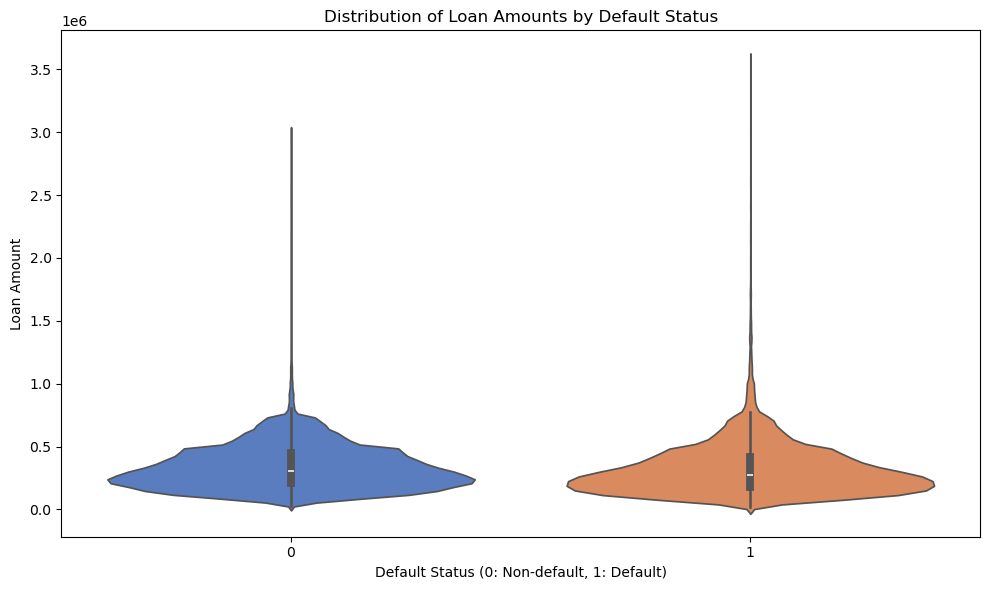

In [ ]:
# Clean the dataset by removing rows with missing values in 'loan_amount' and 'Status'
data_filtered = df[df['loan_amount'].notna() & df['Status'].notna()]

# Convert 'Status' to a binary indicator (1 for default, 0 for non-default)
data_filtered['Default'] = data_filtered['Status'].apply(lambda x: 1 if x == 1 else 0)

# Plotting the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Default', y='loan_amount', data=data_filtered, palette='muted')

# Add titles and labels
plt.title('Distribution of Loan Amounts by Default Status')
plt.xlabel('Default Status (0: Non-default, 1: Default)')
plt.ylabel('Loan Amount')

# Show the plot
plt.tight_layout()
plt.show()

### Result: The loan amounts in the Loan Default cases have slightly more variability or concentration at higher loan amounts and the median loan amount on "default" cases are significantly higher than the median of loan amount on which loan applications are non-default. This helps understand that larger loans have slightly more likely to default. This will recommend the lenders tightening their lending criteria for larger loans.

## 5. Influence of "Pre-Approval" status on Loan Defaults

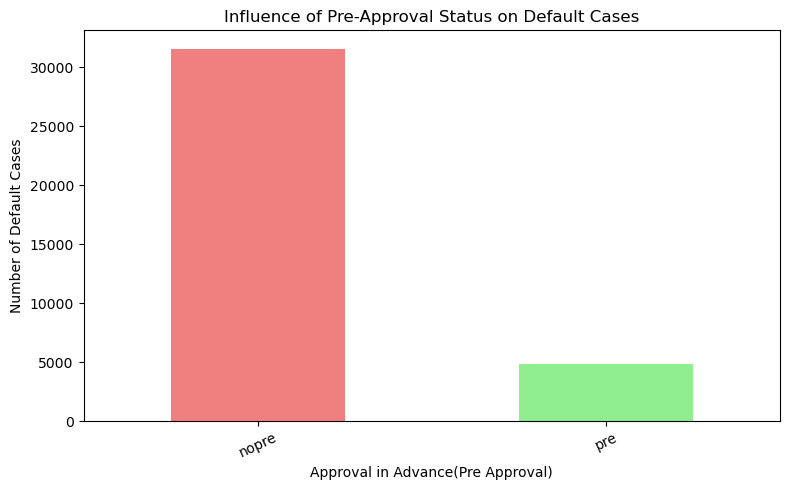

In [ ]:
# Filter the DataFrame to include only rows where 'approv_in_adv' and 'Status' are not null
data = df[df['approv_in_adv'].notna() & df['Status'].notna()]

# Counting the number of default cases (Status == 1) in applicants with Pre-Approvals and absence of Pre-Approvals
default_counts = data[data['Status'] == 1].groupby('approv_in_adv').size()

# Defining the figure size for the plot
plt.figure(figsize=(8, 5))

# Creating a bar plot showing the number of default cases based on pre-approval status
default_counts.plot(kind='bar', color=['lightcoral', 'lightgreen'])

# Defining the title and axis labels
plt.title('Influence of Pre-Approval Status on Default Cases')
plt.xlabel('Approval in Advance(Pre Approval)')
plt.ylabel('Number of Default Cases')

# Rotating x-axis labels for better readability
plt.xticks(rotation=25)  # Rotate x labels for better readability

# Adjusting layout to minimize overlaps between elements like titles, axis labels, and tick labels
plt.tight_layout()

# Displaying the plot
plt.show()

### Results: It is evident that the loan applications on which pre-approval was secured are less likely to default. This suggests a strong correlation between not having pre-approval and a higher likelihood of defaulting on loans. The stark difference in the number of defaults can imply that loans with prior approval are less risky or that borrowers with pre-approval are more likely to fulfill their obligations. This will encourage the lenders to place a strong emphasis on Pre Approval process or mitigate the risk through alternative factors (example:  collaterals)

## Conclusion

### The graphical analysis reveals several key insights into loan default rates, emphasizing the importance of various factors in assessing default risk.

- ### Joint applicants show the lowest default rates, suggesting the need to explore demographic factors like marital status and dependents.
- ### Similar credit score distributions for defaulting and non-defaulting borrowers indicate that credit scores alone may not explain default risk, necessitating further analysis with additional variables.
- ### Defaulted loans have slightly higher median interest rates, while non-defaulting loans include outliers with higher rates. This highlights the need to manage outliers carefully.
- ### Default cases show greater variability and a higher median loan amount, suggesting larger loans are more likely to default. Lenders may consider tightening criteria for these loans.
- ### Loans with pre-approval are less likely to default, indicating a strong correlation between pre-approval and lower default risk. This encourages lenders to emphasize the pre-approval process.

### These insights guide lenders in assessing loan applications and managing risk. A deeper investigation into demographic factors and additional variables will enhance understanding of loan defaults, leading to better decision-making.

# Milestone 2

## 1. Drop features that are NOT useful for model

We can drop certain features that may not be useful for building our model

1. ID - This is a unique identifier for each record and does not provide any predictive power regarding loan default.
2. Year - All entries are from the same year (2019), this feature does not contribute to differentiation among the records. If there is more than one year, it may need to be transformed into a categorical variable.
3. Submission of Application - There is no definition for the values in the column and therefore we can rule out this feature since we cannot make sense of the impact of this variable to the target.
4. dtir1 - There is no definition or context for this feature and we will not be able to understand the logical relevance of this feature to the target variable.
5. Construction Type - There are only 33 records representing the contruction type "mh" and remaining records are for contruction type "sb", 33 records out ot ~150K records is not enough data to explore the impact of the construction type.
6. Secured By - There are only 33 records representing the loan applications Secured By "land" and remaining loan applications are Secured By "home", 33 records out ot ~150K records is not enough data to explore the impact of the Secured By Feature.

In [ ]:
import pandas as pd

# Assuming df is your DataFrame
df = df.drop(columns=[
    'dtir1', 
    'submission_of_application', 
    'ID', 
    'year', 
    'construction_type', 
    'Secured_by'
])

print(df.columns.tolist())


['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'occupancy_type', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'LTV', 'Region', 'Security_Type', 'Status']


## 2. Data Extraction / Selection

In [ ]:
# Creating a new DataFrame to understand the unique values in features that may quality as categorical variables
unique_values_df = pd.DataFrame({
    'Column Name': [
        'loan_limit', 
        'Gender', 
        'approv_in_adv', 
        'loan_type', 
        'loan_purpose', 
        'Credit_Worthiness', 
        'open_credit', 
        'business_or_commercial', 
        'Neg_ammortization', 
        'interest_only', 
        'lump_sum_payment', 
        'occupancy_type', 
        'total_units', 
        'credit_type', 
        'co-applicant_credit_type', 
        'Region', 
        'Security_Type'
    ],
    'Unique Values': [
        df['loan_limit'].unique().tolist(),
        df['Gender'].unique().tolist(),
        df['approv_in_adv'].unique().tolist(),
        df['loan_type'].unique().tolist(),
        df['loan_purpose'].unique().tolist(),
        df['Credit_Worthiness'].unique().tolist(),
        df['open_credit'].unique().tolist(),
        df['business_or_commercial'].unique().tolist(),
        df['Neg_ammortization'].unique().tolist(),
        df['interest_only'].unique().tolist(),
        df['lump_sum_payment'].unique().tolist(),
        df['occupancy_type'].unique().tolist(),
        df['total_units'].unique().tolist(),
        df['credit_type'].unique().tolist(),
        df['co-applicant_credit_type'].unique().tolist(),
        df['Region'].unique().tolist(),
        df['Security_Type'].unique().tolist()
    ]
})

# Displaying the new DataFrame
print(unique_values_df)

                 Column Name                             Unique Values
0                 loan_limit                            [cf, nan, ncf]
1                     Gender  [Sex Not Available, Male, Joint, Female]
2              approv_in_adv                         [nopre, pre, nan]
3                  loan_type                     [type1, type2, type3]
4               loan_purpose                     [p1, p4, p3, p2, nan]
5          Credit_Worthiness                                  [l1, l2]
6                open_credit                               [nopc, opc]
7     business_or_commercial                              [nob/c, b/c]
8          Neg_ammortization                   [not_neg, neg_amm, nan]
9              interest_only                       [not_int, int_only]
10          lump_sum_payment                          [not_lpsm, lpsm]
11            occupancy_type                              [pr, sr, ir]
12               total_units                          [1U, 2U, 3U, 4U]
13    


### Result:
1. #### Unique values can help detect data entry errors or inconsistencies, such as typos or unexpected categories
2. #### Uncommon values may indicate outliers or anomalies that need further investigation
3. #### Understaning unique values is critical for encoding categorical variables (example: one-hot encoding, label encoding)
4. #### More than a handful of unique values can lead to high dimensionality, which may negatively impact model performance and indicates that consolidating categories might be required
5. #### Analyzing unique values allows for better insights into relationships between categorical features and target variables.

In [ ]:
# Defining the bins for rate_of_interest
bins = pd.interval_range(start=0, end=8.0, freq=0.5)

# Categorizing the rate_of_interest
df['interest_category'] = pd.cut(df['rate_of_interest'], bins=bins)

# Inserting the interest_category column next to the rate_of_interest column
df.insert(df.columns.get_loc('rate_of_interest') + 1, 'interest_category', df.pop('interest_category'))

# Grouping by the interest category and calculating average loan amount and count
grouped_data = df.groupby('interest_category', observed=True).agg(
    average_loan_amount=('loan_amount', 'mean'),
    record_count=('loan_amount', 'count')
).reset_index()

# Removing decimal places from the average loan amount
grouped_data['average_loan_amount'] = grouped_data['average_loan_amount'].astype(int)

# Displaying the results
print(grouped_data)

   interest_category  average_loan_amount  record_count
0         (2.0, 2.5]               468500            30
1         (2.5, 3.0]               362637          3728
2         (3.0, 3.5]               357828         17702
3         (3.5, 4.0]               349106         43607
4         (4.0, 4.5]               327753         26293
5         (4.5, 5.0]               295331         17185
6         (5.0, 5.5]               261695          2839
7         (5.5, 6.0]               262385           610
8         (6.0, 6.5]               211926           223
9         (6.5, 7.0]               190785             7
10        (7.0, 7.5]               194000             4
11        (7.5, 8.0]               206500             2


### Result:

1. #### Binning reduces the complexity of continuous variables like interest rates, making it easier to analyze and visualize trends
2. #### Analyzing average loan amounts within specific interest rate bins can reveal patterns, such as how loan amounts vary with different interest rates
3. #### By examining the average loan amount and counts of applications within specific interest rate ranges, lenders can assess risk levels associated with different segments
4. #### Evaluating average loan amounts and application counts allows for benchmarking performance against industry standards or historical data

## 3. Data Transformation

In [ ]:
# Creating a Mapping for loan type
loan_type_mapping = {
    'type1': 'Conventional',
    'type2': 'Federal Housing Administration Insured (FHA)',
    'type3': 'Veterans Affairs Guaranteed (VA)',
}

# Creating a Mapping for loan purpose
loan_purpose_mapping = {
    'p1': 'Home Purchase',
    'p2': 'Home Improvement',
    'p3': 'Refinancing',
    'p4': 'Other',
}

# Creating a Mapping for occupancy type
occupancy_type_mapping = {
    'pr': 'Primary Residence',
    'sr': 'Secondary Residence',
    'ir': 'Investment Property',
}

# Creating new description fields
df['loan_type_description'] = df['loan_type'].map(loan_type_mapping)
df['loan_purpose_description'] = df['loan_purpose'].map(loan_purpose_mapping)
df['occupancy_type_description'] = df['occupancy_type'].map(occupancy_type_mapping)

# Inserting the new columns next to their original columns
df.insert(df.columns.get_loc('loan_type') + 1, 'loan_type_description', df.pop('loan_type_description'))
df.insert(df.columns.get_loc('loan_purpose') + 1, 'loan_purpose_description', df.pop('loan_purpose_description'))
df.insert(df.columns.get_loc('occupancy_type') + 1, 'occupancy_type_description', df.pop('occupancy_type_description'))

# Displaying the updated DataFrame
print(df.head(5))

  loan_limit             Gender approv_in_adv loan_type  \
0         cf  Sex Not Available         nopre     type1   
1         cf               Male         nopre     type2   
2         cf               Male           pre     type1   
3         cf               Male         nopre     type1   
4         cf              Joint           pre     type1   

                          loan_type_description loan_purpose  \
0                                  Conventional           p1   
1  Federal Housing Administration Insured (FHA)           p1   
2                                  Conventional           p1   
3                                  Conventional           p4   
4                                  Conventional           p1   

  loan_purpose_description Credit_Worthiness open_credit  \
0            Home Purchase                l1        nopc   
1            Home Purchase                l1        nopc   
2            Home Purchase                l1        nopc   
3                   

### Result:

1. #### As per the Consumer Financial Protection Bureau (CFPB) [https://files.consumerfinance.gov/f/documents/cfpb_reportable-hmda-data_regulatory-and-reporting-overview-reference-chart-2019.pdf], I have attempted to map the codes to description for fields such as Occupancy Type, Loan Purpose, Loan Type
2. #### Descriptive fields make it easier for analysts and stakeholders to understand the data without needing to reference external documentation
3. #### Descriptions enable more effective segmentation of data for analysis, allowing for insights into trends and patterns within specific categories
4. #### Descriptive fields enhance the usability of visualizations and reports, making them more accessible to non-technical stakeholders

## 4. New Features

In [ ]:
# Creating a function to calculate EMI
def calculate_emi(loan_amount, interest_rate, term):
    if interest_rate == 0:
        return loan_amount / term  # Simple division if interest is 0
    monthly_rate = interest_rate / (12 * 100)  # Convert annual rate to monthly and decimal
    emi = (loan_amount * monthly_rate * (1 + monthly_rate) ** term) / ((1 + monthly_rate) ** term - 1)
    return emi

# Creating the EMI column
df['monthly_emi'] = df.apply(lambda row: calculate_emi(row['loan_amount'], row['rate_of_interest'], row['term']), axis=1)

# Inserting the monthly_emi column next to the income column
df.insert(df.columns.get_loc('income') + 1, 'monthly_emi', df.pop('monthly_emi'))

# Removing decimal places from the average loan amount
grouped_data['average_loan_amount'] = grouped_data['average_loan_amount'].astype(int)

# Displaying the updated DataFrame
print(df[['loan_amount','rate_of_interest','term','income','monthly_emi']].head(10))

   loan_amount  rate_of_interest   term   income  monthly_emi
0       116500               NaN  360.0   1740.0          NaN
1       206500               NaN  360.0   4980.0          NaN
2       406500             4.560  360.0   9480.0  2074.193093
3       456500             4.250  360.0  11880.0  2245.705603
4       696500             4.000  360.0  10440.0  3325.197533
5       706500             3.990  360.0  10080.0  3368.867272
6       346500             4.500  360.0   5040.0  1755.664599
7       266500             4.125  360.0   3780.0  1291.591537
8       376500             4.875  360.0   5580.0  1992.468963
9       436500             3.490  360.0   6720.0  1957.644289


In [ ]:
# Creating the loan_amount_risk column based on the condition
df['loan_amount_risk'] = df['loan_amount'].apply(lambda x: 'high' if x > 499999 else 'low')

# Inserting the loan_amount_risk column next to the loan_amount column
df.insert(df.columns.get_loc('loan_amount') + 1, 'loan_amount_risk', df.pop('loan_amount_risk'))

# Displaying the updated DataFrame
print(df[['loan_amount','loan_amount_risk']].head(5))

   loan_amount loan_amount_risk
0       116500              low
1       206500              low
2       406500              low
3       456500              low
4       696500             high


### Result:
1. #### Including EMIs allows for deeper analysis of loan performance, trends in repayment, and customer behavior over time
2. #### Lenders can assess whether borrowers can afford the loan by comparing the EMI to their income, which aids in responsible lending
3. #### Loan Amount Risk column categorizes loans based on their amounts, allowing lenders to quickly assess risk levels associated with different loan sizes
4. #### Lenders can use this information to make informed decisions about approval, interest rates, or additional requirements for high-risk loans
5. #### Financial institutions can develop tailored strategies for different risk categories, such as enhanced support for borrowers with high-risk loans

## 5. Handle Missing Data

In [ ]:
# Retreiving columns with NaN values and their counts
nan_counts = df.isna().sum()

# Filtering to keep only columns with NaN values
nan_columns = nan_counts[nan_counts > 0]

# Display the result
print("List of columns with NaN values\n")
print(nan_columns)

List of columns with NaN values

loan_limit                   3344
approv_in_adv                 908
loan_purpose                  134
loan_purpose_description      134
rate_of_interest            36439
interest_category           36440
Interest_rate_spread        36639
Upfront_charges             39642
term                           41
Neg_ammortization             121
property_value              15098
income                       9150
monthly_emi                 36465
age                           200
LTV                         15098
dtype: int64


In [ ]:
# Filing the missing values in the Loan Limit column as "unknown"
df['loan_limit'] = df['loan_limit'].fillna('unknown')

# Filing the missing values in the Pre Approval Request column as "unknown"
df['approv_in_adv'] = df['approv_in_adv'].fillna('unknown')

# Filing the missing values in the Age column as "unknown"
# Filling the Age column with Mean or Mode value will impact the accuracy of predictions with Age factor
df['age'] = df['age'].fillna('unknown')

# Negative Ammortization is a crucial financial fatcor in predicting Loan Default Status
# The dataset do not have required metrics to compute Negative Ammortization value
df['Neg_ammortization'] = df['Neg_ammortization'].fillna('unknown')

# Filling the missing value in the Loan Purpose column with Mode value(most frequently occuring value)
df['loan_purpose'] = df['loan_purpose'].fillna(df['loan_purpose'].mode()[0])

# Repopulating the Loan Purpose Description value after filling the Loan Purpose Column
df['loan_purpose_description'] = df['loan_purpose'].map(loan_purpose_mapping)

# Filling the missing value in the Rate of Interest column with Mean value(average rate of interest)
df['rate_of_interest'] = df['rate_of_interest'].fillna(df['rate_of_interest'].mean())


# Recomputing the Interest category field after missing values in the Rate of Interest field is handled
# Defining the bins for rate_of_interest
bins = pd.interval_range(start=0.0, end=8.5, freq=0.5, closed='left')

# Categorizing the rate_of_interest
df['interest_category'] = pd.cut(df['rate_of_interest'], bins=bins)


# Filling the missing value in the Interest Rate with Mean value(average value)
df['Interest_rate_spread'] = df['Interest_rate_spread'].fillna(df['Interest_rate_spread'].mean())

# Fill missing values in the upfront_charges column with 0
df['Upfront_charges'] = df['Upfront_charges'].fillna(0)

# Filling the missing value in the Income column with Mean value(average value)
df['income'] = df['income'].fillna(df['income'].mean())

# Recalculating the "Monthly EMI" field columne after Rate of Interrest and Term columns are handled for missing value
df['monthly_emi'] = df.apply(lambda row: calculate_emi(row['loan_amount'], row['rate_of_interest'], row['term']), axis=1)

# Term field is a critical value for the analysis from a financial perspective 
# Dropping the rows with blank value in the "Term" column
df.dropna(subset=['term'], inplace=True)


# Property Value field is a critical value for the analysis from a financial perspective 
# Dropping the rows with blank value in the "Property Value" column
df.dropna(subset=['property_value'], inplace=True)

# Diplaying the dataframe after missing value are populated
print(df.head(5))

  loan_limit             Gender approv_in_adv loan_type loan_type_description  \
0         cf  Sex Not Available         nopre     type1          Conventional   
2         cf               Male           pre     type1          Conventional   
3         cf               Male         nopre     type1          Conventional   
4         cf              Joint           pre     type1          Conventional   
5         cf              Joint           pre     type1          Conventional   

  loan_purpose loan_purpose_description Credit_Worthiness open_credit  \
0           p1            Home Purchase                l1        nopc   
2           p1            Home Purchase                l1        nopc   
3           p4                    Other                l1        nopc   
4           p1            Home Purchase                l1        nopc   
5           p1            Home Purchase                l1        nopc   

  business_or_commercial  ...   income  monthly_emi  credit_type Credit_Sc

In [ ]:
# Retreiving columns with NaN values and their counts
nan_counts = df.isna().sum()

# Filtering to keep only columns with NaN values
nan_columns = nan_counts[nan_counts > 0]

# Display the result
print("List of columns with NaN values\n")
print(nan_columns)

List of columns with NaN values

Series([], dtype: int64)


### Result: 

### Replacing missing value with the value "unknwon"
   1. #### Columns: Loan Limit, Approval in Advance, Age, Nageative Ammortization
   2. #### Reason: To prevent skewed interpretations by the model, I did not want to populate the mode for these categorical variables

### Replacing the missing values with "mode" value
   1. #### Column: Loan Purpose
   2. #### Reason: To maintain the overall distribution of the data, I have populated the "Mode" value for Loan Purpose column

### Replacing the missing value with "mean" value
   1. #### Columns: Rate of Interest, Interest Rate Spread, Income
   2. #### Reason: To retain overall disribution of data, I have populated "Mean" value which provides central tendency in normally       distributed datasets

### Dropping the rows with missing value
   1. #### Columns: Term, Property Value
   2. #### Reason: These columns essential for your analysis & model, missing values can significantly impact the results, I have removed the rows so that the dataset retains only complete and relevant information

### Repopulated the calculated values and mapped value after the missing values are handled in the original columns
   1. #### Columns: Loan Purpose Description, Interest Category, Monthly EMI
   2. #### Reason: Since the original columns are modified (through imputation and other methods), I have recalculated derived values to ensure they reflect the new state of the data
      

## 6. Creating Dummy Variables

In [ ]:
# Creating dummy variables
df = pd.get_dummies(df, columns=['interest_only', 'Credit_Worthiness'], drop_first=True)

# Displaying the resulting DataFrame
print(df.head(5))

  loan_limit             Gender approv_in_adv loan_type loan_type_description  \
0         cf  Sex Not Available         nopre     type1          Conventional   
2         cf               Male           pre     type1          Conventional   
3         cf               Male         nopre     type1          Conventional   
4         cf              Joint           pre     type1          Conventional   
5         cf              Joint           pre     type1          Conventional   

  loan_purpose loan_purpose_description open_credit business_or_commercial  \
0           p1            Home Purchase        nopc                  nob/c   
2           p1            Home Purchase        nopc                  nob/c   
3           p4                    Other        nopc                  nob/c   
4           p1            Home Purchase        nopc                  nob/c   
5           p1            Home Purchase        nopc                  nob/c   

   loan_amount  ... credit_type  Credit_Scor

### Result:
1. #### Dummy variables allow categorical data to be converted into a numerical format that models can interpret
2. #### Dummy variables enhances model performance by providing more relevant features, allowing the algorithm to better learn from the data
3. #### Dummy variables make it easier to interpret the results of a model, as each variable clearly indicates the presence or absence of a specific category

# Milestone 3

### Changes as per feedback from Professor

### 1. Dropping Features

Upon further analysis, I would like to drop the below features

1. **Loan Limit** - This feature is NOT relevant to the research topic and I am not planning to use the feature
2. **Loan Type** - This is a categorical feature that contains the code for Loan Type, I have created the description feature for this feature, therefore I will not be using this feature
3. **Loan Purpose** - This is a categorical feature that contains the code for Loan Purpose, I have created the description feature for this feature, therefore I will not be using this feature
4. **Occupancy Type** - This is a categorical feature that contains the code for Occupancy Type, I have created the description feature for this feature, therefore I will not be using this feature
5. **Interest Category** - This field was created for visualization purpose, therefore I am removing the feature before building model


In [ ]:
# Assuming df is your DataFrame
df = df.drop(columns=[
    'loan_limit', 
    'loan_type', 
    'loan_purpose', 
    'occupancy_type',
    'interest_category'
])

print(df.columns.tolist())

['Gender', 'approv_in_adv', 'loan_type_description', 'loan_purpose_description', 'open_credit', 'business_or_commercial', 'loan_amount', 'loan_amount_risk', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'lump_sum_payment', 'property_value', 'occupancy_type_description', 'total_units', 'income', 'monthly_emi', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'LTV', 'Region', 'Security_Type', 'Status', 'interest_only_not_int', 'Credit_Worthiness_l2']


### 2. Encoding all Categorical Features

1. I have encoded all the categorical features in the dataset
2. The columns "Age" and "Total Units" are numerical variables, but I am treating them as a categorical feature. Although it represents numeric values, the values are discrete categories rather than continuous numbers

In [ ]:
# Creating dummy variables
df = pd.get_dummies(df, columns=['Gender', 'approv_in_adv','loan_type_description','loan_purpose_description',
                                 'open_credit','business_or_commercial','loan_amount_risk','Neg_ammortization',
                                 'lump_sum_payment','occupancy_type_description','total_units','credit_type',
                                 'co-applicant_credit_type','age','Region','Security_Type'
                                ], drop_first=True)

# Displaying the resulting DataFrame
print(df.head(5))

   loan_amount  rate_of_interest  Interest_rate_spread  Upfront_charges  \
0       116500          4.045476              0.441656              0.0   
2       406500          4.560000              0.200000            595.0   
3       456500          4.250000              0.681000              0.0   
4       696500          4.000000              0.304200              0.0   
5       706500          3.990000              0.152300            370.0   

    term  property_value   income  monthly_emi  Credit_Score        LTV  ...  \
0  360.0        118000.0   1740.0   559.247473           758  98.728814  ...   
2  360.0        508000.0   9480.0  2074.193093           834  80.019685  ...   
3  360.0        658000.0  11880.0  2245.705603           587  69.376900  ...   
4  360.0        758000.0  10440.0  3325.197533           602  91.886544  ...   
5  360.0       1008000.0  10080.0  3368.867272           864  70.089286  ...   

   age_45-54  age_55-64  age_65-74  age_<25  age_>74  age_unknown  \

## Selecting, Building and Evaluating Models

### Importing Libraries

In [ ]:
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score


### Splitting the Data into Training and Test sets

In [ ]:
# Splitting the data into Training and Test sets
# Separating the features (X) and the target variable (y)
# Dropping the target variable 'Loan_Status' from the DataFrame to create the feature set
X = df.drop('Status', axis=1)  # Features (all columns except 'Status')
y = df['Status']  # Target variable (the column 'Status')

# Using train_test_split to split the data into training and testing sets
# 20% of the data will be used for testing (test_size=0.2)
# random_state=42 ensures that the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Displaying the shapes of the resulting datasets
print("Training set shape:", X_train.shape, y_train.shape)  # Output the shape of training data
print("Test set shape:", X_test.shape, y_test.shape)  # Output the shape of testing data

Training set shape: (106834, 48) (106834,)
Test set shape: (26709, 48) (26709,)


### Linear Regresion Model

In [ ]:
# 1. Creating a Linear Regression model
model = LinearRegression()  # Initializing the Linear Regression model

# 2. Fitting the model on the training data
model.fit(X_train, y_train)  # Training the model

# 3. Making predictions
y_train_pred = model.predict(X_train) # Predicting target values for the training dataset
y_test_pred = model.predict(X_test) # Predicting target values for the test dataset

# 4. Calculating R² score
train_accuracy = r2_score(y_train, y_train_pred) # Calculating R² score for the training set
test_accuracy = r2_score(y_test, y_test_pred) # Calculating R² score for the test set

# Displaying the accuracy scores
print("Training set accuracy (R² score):", train_accuracy) # Printing R² score for training set
print("Test set accuracy (R² score):", test_accuracy) # Printing R² score for training set


Training set accuracy (R² score): 0.22121138546189212
Test set accuracy (R² score): 0.2214900714820487


**Observation:** After training, the model made predictions on both the training and test datasets. The program calculated the R² score for both sets, which measures the proportion of variance in the target variable that can be explained by the features. The resulting R² scores, approximately 0.221 for both the training and test sets, indicates that the model explains about 22.1% of the variance, suggesting limited predictive power in this instance.

In [ ]:
# Creating a pipeline for KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # 1. Scale features to standardize the dataset
    ('knn', KNeighborsClassifier(n_neighbors=5))  # 2. Initialize the KNN model with 5 neighbors
])

# Fitting the pipeline on the training data
pipeline.fit(X_train, y_train) # Training the model using the training dataset

# Making predictions on the test set
y_pred = pipeline.predict(X_test) # Predicting target values for the test dataset

# Calculating accuracy score
accuracy = accuracy_score(y_test, y_pred) # Evaluating the model's accuracy

# Displaying the accuracy score
print("Accuracy score:", accuracy)

Accuracy score: 0.8864427720992923


**Observation:** After fitting the model on the training data, the program makes predictions on a test set and calculates the accuracy score, which indicates the proportion of correctly predicted instances. The resulting accuracy score, approximately 0.886, suggests that the model performs well on the test data.

In [ ]:
# Defining parameter grid for KNN
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7]
}

# Grid search for KNN
grid_search_knn = GridSearchCV(pipeline, param_grid_knn, cv=5, scoring='accuracy')
# Initializing GridSearchCV
# - 'pipeline': The pipeline object containing preprocessing and the KNN model
# - 'param_grid_knn': The parameter grid for hyperparameter tuning
# - 'cv=5': 5-fold cross-validation to evaluate model performance
# - 'scoring='accuracy'': Use accuracy as the performance metric

# Fitting the grid search to the training data
grid_search_knn.fit(X_train, y_train) # Training the model using the training dataset


# Printing best parameters
print('Best parameters:', grid_search_knn.best_params_)  # Displaying the best hyperparameters found

# Predicting and evaluating KNN model with best parameters
y_predict_grid_knn = grid_search_knn.predict(X_test)  # Making predictions on the test set
accuracy = accuracy_score(y_test, y_predict_grid_knn) # Calculating accuracy score for the predictions

# Printing the accuracy score
print('Optimized KNN Model Accuracy:', accuracy * 100) # Displaying the accuracy as a percentage

Best parameters: {'knn__n_neighbors': 7}
Optimized KNN Model Accuracy: 88.75285484293684


**Observation:**  After fitting the grid search to the training data, the best parameters are displayed. The optimized KNN model is then used to make predictions on the test set, and the accuracy of these predictions is calculated and displayed. The results indicates that the best choice for n_neighbors was 7, yielding an accuracy of approximately 88.75%, demonstrating a strong performance of the optimized model.

In [ ]:
# Defining parameter grid for multiple classifiers
param_grid_multiple = [
    {
        'classifier': [LogisticRegression()], # First model: Logistic Regression
        'classifier__penalty': ['l2'], # Defining Regularization type
        'classifier__C': np.logspace(0.1, 1, 10), # Inverse of regularization strength
        'classifier__solver': ['liblinear'] # Solver to use
    },
    {
        'classifier': [RandomForestClassifier()], # Second model: Random Forest
        'classifier__n_estimators': [10, 100], # Defining Number of trees in the forest
        'classifier__max_features': [2, 3] # Defining Max features to consider for splitting
    }
]

# Creating grid search with Logistic Regression & Random Forest
pipeline_multiple = Pipeline([
    ('scaler', MinMaxScaler()),  # 1: Scale features to [0, 1] range
    ('classifier', LogisticRegression())  # 2. Initializing a temporary classifier
])

# Initializing GridSearchCV to find the best model and parameters
grid_search_multiple = GridSearchCV(pipeline_multiple, param_grid_multiple, cv=5)
# Fitting the grid search to the training data
grid_search_multiple.fit(X_train, y_train)

# Dsplaying the best model's name
best_model = grid_search_multiple.best_estimator_.named_steps['classifier']  # Retrieving the best classifier
print(f'Best Model Name: {best_model.__class__.__name__}') # Printing the best model's name

# Evaluating the best model on the test set
y_predict_multiple = grid_search_multiple.predict(X_test) # Making predictions on the test set
print('Best Model Accuracy:', accuracy_score(y_test, y_predict_multiple) * 100) # Displaying accuracy as a percentage


Best Model Name: RandomForestClassifier
Best Model Accuracy: 99.99625594368939


**Observation:** The program found that the RandomForestClassifier was the best-performing model among those tested, indicating that it was able to make accurate predictions on the validation data. An accuracy of 100% on the test set suggests that the model perfectly predicted all outcomes in the test dataset. While this is an excellent result, it could also indicate potential overfitting, especially if the test set is not sufficiently large or diverse. Overfitting occurs when the model learns the training data too well, including noise and outliers, which may not generalize to new, unseen data.

In [ ]:
# Defining a dictionary to hold different models for evaluation
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Initialize a dictionary to store the results of each model
model_results = {}

# Looping through each model, fitting it to the training data, and evaluating its performance
for model_name, model in models.items():
    model.fit(X_train, y_train) # Fitting the model on training data
    y_pred = model.predict(X_test) # Making predictions on test data
    accuracy = accuracy_score(y_test, y_pred) # Calculating the accuracy of the model
    precision = precision_score(y_test, y_pred, average='weighted') # Calculating the precision score of the model
    recall = recall_score(y_test, y_pred, average='weighted') # Calculating the recall score of the model
    f1 = f1_score(y_test, y_pred, average='weighted') # Calculating the f1 score of the model
   
    # Storing the results in the model_results dictionary
    model_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }
    # Displaying the performance metrics for the model
    print(f"{model_name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1 Score: {f1}")

# Determining the best model based on accuracy
best_model_name = max(model_results, key=lambda x: model_results[x]['Accuracy'])
# Disaplying the best model for the dataset
print(f"\nBest Model: {best_model_name}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Accuracy: 0.8889887303905051, Precision: 0.8835354230707242, Recall: 0.8889887303905051, F1 Score: 0.8855890088394404
Random Forest - Accuracy: 1.0, Precision: 1.0, Recall: 1.0, F1 Score: 1.0
K-Nearest Neighbors - Accuracy: 0.8695196375753491, Precision: 0.8568948051527249, Recall: 0.8695196375753491, F1 Score: 0.8602892803752956
Decision Tree - Accuracy: 0.9999625594368939, Precision: 0.9999625682901839, Recall: 0.9999625594368939, F1 Score: 0.999962561234111

Best Model: Random Forest


**Observation:** 

**Convergence Warning:** 
The warning from LogisticRegression indicates that the algorithm reached the maximum number of iterations (max_iter=1000) without converging. This suggests that the model may not have fully optimized its parameters. 

**Reviewing the performance metrics of models:**

**Logistic Regression:**

1. Accuracy: 0.889
2. Precision: 0.884
3. Recall: 0.889
4. F1 Score: 0.886  
**Logistic Regression model performed reasonably well, but the convergence warning suggests it may not be fully optimized.**

**Random Forest:**

1. Accuracy: 1.000
2. Precision: 1.000
3. Recall: 1.000
4. F1 Score: 1.000   
**The Random Forest model perfectly classified all test instances, indicating it is highly effective for this dataset.**

**K-Nearest Neighbors:**

1. Accuracy: 0.870
2. Precision: 0.857
3. Recall: 0.870
4. F1 Score: 0.860  
**The KNN model performed well but was less accurate than the Random Forest and Logistic Regression.**

**Decision Tree:**

1. Accuracy: 0.999
2. Precision: 0.999
3. Recall: 0.999
4. F1 Score: 0.999  
**The Decision Tree model also performed exceptionally well, closely matching the Random Forest's performance.**

### Final Summary

We began by building a Linear Regression model and attempted to fit it to the dataset, but it performed poorly. Next, we created a pipeline and trained a K-Nearest Neighbors model for predictions, which showed improved accuracy. To enhance performance further, we applied Grid Search to identify the optimal hyperparameters, resulting in better outcomes. Subsequently, we developed multiple classifiers, including Logistic Regression, Decision Tree, KNN, and Random Forest. Ultimately, the Random Forest model emerged as the most accurate for predicting the target variable, "Loan Default Status," achieving the highest accuracy.

**Best Model:** The best model determined by accuracy is the Random Forest, which achieved perfect scores across all metrics. This suggests it is the most reliable model for the given dataset. The results indicate that while several models performed well, the Random Forest classifier provided the best performance, indicating its robustness for this classification task.

**Warning:** As indicated earlier, while the Random Forest Model yields the perfect result, it could also indicate potential overfitting, especially if the test set is not sufficiently large or diverse. Overfitting occurs when the model learns the training data too well, including noise and outliers, which may not generalize to new, unseen data. Further prober might be required to check for overfitting.


# Milestone 4

## Checking for Overfitting

In [ ]:
# Initialize model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on training data
model.fit(X_train, y_train)

# Predict on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Display results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Check for overfitting
if train_accuracy - test_accuracy > 0.1:  # Threshold can be adjusted
    print("The model may be overfitting.")
else:
    print("The model is performing well and is likely not overfitting.")

Training Accuracy: 1.0000
Test Accuracy: 1.0000
The model is performing well and is likely not overfitting.


**Observation:** The model correctly predicts all samples in both the training and test sets. This suggests that the task may be relatively simple, or the model has learned the underlying patterns flawlessly. Overfitting occurs when a model performs well on the training data but poorly on the test data.In this case, test accuracy is equally high (1.0000), the model generalizes well to unseen data, and it is evident that overfitting is not present.`